# Korea Revenue Forecast — 조회 · 분석 · 시각화 노트북 v2

**예측 결과 테이블** : `korea_revenue_forecast_result` *(indicator: SARIMA / ETS / Theta / Ensemble)*  
**실제값 원천 테이블** : `korea_fs_data_from_DG` *(item_code = 'M000904001', 매출액 (천원))*

### 성장률 측정 기준
| 구분 | 계산 방법 |
|------|----------|
| **4Q 성장률** | 예측 향후 4분기 합산 ÷ 직전 실제 4분기 합산 − 1 |
| **8Q 성장률** | 예측 향후 8분기 합산 ÷ 최근 실제 8분기 합산 − 1 |
| **기간 CAGR** | 기하평균 기반 연환산 성장률 |

---

### v2 변경 사항 (v1 대비)
| 변경 | 이유 |
|------|------|
| **이상치 자동 필터링** (`MAX_GROWTH_PCT`, `MAX_FC_RATIO`) | SARIMA/ETS가 일부 종목에서 발산하여 천문학적 값 출력 → 표 레이아웃 붕괴 방지 |
| **표시 단위를 '억원'으로 변환** | 천원 단위 큰 숫자를 그대로 표시하면 셀 폭이 무한 확장 |
| **`anomaly_df` 별도 반환** | 발산 종목을 추적/검증 가능 |
| **셀 폭 max-width 제한** | 단일 이상치가 표 전체를 깨뜨리지 못하도록 방어 |
| **진단 셀 (Cell 11)** 추가 | 발산 종목·모델별 통계 즉시 확인 |

---

| 셀 | 단계 |
|---|---|
| Cell 1 | 환경 설정 & 경로 자동 감지 |
| Cell 2 | 라이브러리 Import & DB 연결 |
| Cell 3 | 파라미터 설정 (이상치 임계값 포함) |
| Cell 4 | 핵심 계산 함수 정의 |
| Cell 5 | 단일 티커 예측치 조회 함수 (`fetch_forecast`) |
| Cell 6 | 단일 티커 조회 테스트 + 증감률 표 |
| Cell 7 | Best-N 기업 추출 함수 (`get_best_n`) |
| Cell 8 | Best-N 추출 테스트 (정상값) |
| Cell 9 | **발산 종목 진단 (`anomaly_df`)** |
| Cell 10 | 단일 티커 시각화 (`plot_ticker_forecast`) |
| Cell 11 | Best-N 성장률 비교 막대 차트 (`plot_best_n_growth`) |


## Cell 1 · 환경 설정 & 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve()
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root (자동 감지): {root}")
            return root
    for c in _CANDIDATE_ROOTS:
        if os.path.isdir(c):
            if c not in sys.path:
                sys.path.insert(0, c)
            print(f"[PATH] root (후보 경로): {c}")
            return c
    raise EnvironmentError("DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS를 수정하세요.")

_root = _setup_path()
print(f"[확인] sys.path[0] = {sys.path[0]}")


[PATH] root (자동 감지): C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] sys.path[0] = C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Korea_Market\analysis\한국기업_매출예측


## Cell 2 · 라이브러리 Import & DB 연결

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

matplotlib.rcParams["font.family"]       = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from DATA.config import get_db_info, get_engine, log

db_info = get_db_info()
engine  = get_engine(db_info)

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("[OK] DB 연결 성공")
    print(f"     host={db_info['host']}  port={db_info['port']}  db={db_info['database']}")
except Exception as e:
    print(f"[FAIL] DB 연결 실패: {e}")


[OK] DB 연결 성공
     host=192.168.0.230  port=3307  db=investar


## Cell 3 · 파라미터 설정

이 셀에서 이상치 필터링 임계값(`MAX_GROWTH_PCT`, `MAX_FC_RATIO`)을 조정할 수 있습니다.


In [3]:
# ── 예측 결과 테이블 (Korea_revenue_forecast_.py 의 저장 대상) ──
FORECAST_TABLE = "korea_revenue_forecast_result"

# ── 실제값 원천 테이블 (DataGuide 변환본) ──
FS_TABLE          = "korea_fs_data_from_DG"
REVENUE_ITEM_CODE = "M000904001"   # 매출액 (천원)

# ── ticker 형식: True 면 'A005930' (A 접두사 포함) ──
TICKER_HAS_A_PREFIX = True

# ──────────────────────────────────────────────────────────────────────
# 이상치(발산) 필터링 임계값  ── v2 신규
# ──────────────────────────────────────────────────────────────────────
# SARIMA/ETS 같은 모델이 외삽 시 발산하면 매출 예측값이 천문학적으로 커진다.
# 그 결과 styler 의 cell 폭이 폭발해 표 전체 레이아웃이 깨진다.
# 다음 두 임계값으로 명백한 발산 케이스를 best_df 에서 제외한다.
MAX_GROWTH_PCT = 1000.0      # |4Q 또는 8Q 성장률| > 1000% (=10배 성장) 면 발산으로 간주
MAX_FC_RATIO   = 50.0        # 예측 4Q 합 ÷ 실제 4Q 합 비율 > 50배 면 발산으로 간주

# ── 차트 색상 ──
ACTUAL_COLOR   = "#2C3E50"
FORECAST_COLOR = "#E74C3C"
BAR_PALETTE    = [
    "#2ECC71","#3498DB","#9B59B6","#F39C12","#E74C3C",
    "#1ABC9C","#E67E22","#34495E","#E91E63","#00BCD4",
    "#8BC34A","#FF5722","#607D8B","#795548","#9C27B0",
    "#03A9F4","#CDDC39","#FF9800","#673AB7","#009688",
]


def normalize_ticker(ticker) -> str:
    '''
    'A005930' / '005930' / 5930 → 'A005930' (또는 '005930') 으로 통일
    '''
    if isinstance(ticker, int):
        raw = f"{ticker:06d}"
    else:
        raw = str(ticker).strip()
    body = raw[1:] if raw.upper().startswith('A') else raw
    body = body.zfill(6)
    return f"A{body}" if TICKER_HAS_A_PREFIX else body


print("[OK] 파라미터 설정 완료")
print(f"     MAX_GROWTH_PCT = {MAX_GROWTH_PCT}%   (이 값 초과 종목은 발산으로 간주)")
print(f"     MAX_FC_RATIO   = {MAX_FC_RATIO}배   (이 비율 초과 종목은 발산으로 간주)")


[OK] 파라미터 설정 완료
     MAX_GROWTH_PCT = 1000.0%   (이 값 초과 종목은 발산으로 간주)
     MAX_FC_RATIO   = 50.0배   (이 비율 초과 종목은 발산으로 간주)


## Cell 4 · 핵심 계산 함수 정의

```
4Q 성장률  = (예측 향후 4Q 합산) / (직전 실제 4Q 합산) - 1
8Q 성장률  = (예측 향후 8Q 합산) / (최근 실제 8Q 합산) - 1
CAGR       = (말기값 / 기초값)^(1/n_years) - 1
```

> 한국 매출 데이터는 **'천원'** 단위. 시각화/표시 단계에서는 자동으로 **억원** 단위로 변환됩니다 (1 억원 = 100,000 천원).


In [4]:
def calc_growth_4q(actual_vals: list, forecast_vals: list):
    '''4Q 성장률: 예측 향후 4Q 합산 / 직전 실제 4Q 합산 - 1'''
    if len(actual_vals) < 4 or len(forecast_vals) < 4:
        return None
    base   = sum(actual_vals[-4:])
    target = sum(forecast_vals[:4])
    if base == 0 or not np.isfinite(base) or not np.isfinite(target):
        return None
    return (target / base - 1) * 100


def calc_growth_8q(actual_vals: list, forecast_vals: list):
    '''8Q 성장률: 예측 향후 8Q 합산 / 최근 실제 8Q 합산 - 1'''
    if len(actual_vals) < 8 or len(forecast_vals) < 8:
        return None
    base   = sum(actual_vals[-8:])
    target = sum(forecast_vals[:8])
    if base == 0 or not np.isfinite(base) or not np.isfinite(target):
        return None
    return (target / base - 1) * 100


def calc_cagr(start_val: float, end_val: float, n_quarters: int):
    '''기하평균 기반 CAGR (연환산). n_quarters = 기간(분기 수)'''
    if start_val is None or end_val is None:
        return None
    if (not np.isfinite(start_val)) or (not np.isfinite(end_val)):
        return None
    if start_val <= 0 or end_val <= 0 or n_quarters <= 0:
        return None
    n_years = n_quarters / 4.0
    try:
        return ((end_val / start_val) ** (1.0 / n_years) - 1) * 100
    except (OverflowError, ValueError):
        return None


def calc_qoq(prev_val: float, curr_val: float):
    '''단순 QoQ 증감률 (연환산 아님)'''
    if prev_val is None or prev_val == 0:
        return None
    if (not np.isfinite(prev_val)) or (not np.isfinite(curr_val)):
        return None
    return (curr_val / prev_val - 1) * 100


def unit_divisor(max_val: float):
    '''
    값 크기에 따른 단위 자동 결정 → (divisor, label)

    매출 데이터가 '천원' 단위로 저장되어 있다고 가정.
        1e9 (천원) = 1 조 원       → '조'
        1e6 (천원) = 10 억 원      → '십억'
        1e3 (천원) = 100 만 원     → '백만'
        else                        → '천'
    '''
    if max_val >= 1e9: return 1e9, "조"
    if max_val >= 1e6: return 1e6, "십억"
    if max_val >= 1e3: return 1e3, "백만"
    return 1, "천"


def qtr_label(dt) -> str:
    '''datetime → YYYY\nQN 형식 레이블'''
    q = (dt.month - 1) // 3 + 1
    return f"{dt.year}\nQ{q}"


# ── styler용 포매터 (v2 신규) ─────────────────────────────────────
def fmt_eok(v):
    '''천원 단위 값을 억원 단위로 변환해 표시 (1 억원 = 100,000 천원)'''
    if v is None:
        return "-"
    if isinstance(v, float) and (not np.isfinite(v)):
        return "발산"
    return f"{v / 1e5:,.0f}"


def fmt_pct(v):
    if v is None or (isinstance(v, float) and (not np.isfinite(v))):
        return "-"
    return f"{v:+.2f}%"


def fmt_pct_yr(v):
    if v is None or (isinstance(v, float) and (not np.isfinite(v))):
        return "-"
    return f"{v:+.2f}%/yr"


print("[OK] 계산 함수 정의 완료")
print("     fmt_eok(v) : '천원' 단위 → '억원' 단위 자동 변환 포매터")


[OK] 계산 함수 정의 완료
     fmt_eok(v) : '천원' 단위 → '억원' 단위 자동 변환 포매터


## Cell 5 · 단일 티커 예측치 조회 함수

`fetch_forecast(ticker, model)` 반환값
- `actual_df` / `forecast_df` : 시계열 DataFrame
- `growth_df`  : 예측 구간 QoQ + 누적 CAGR 표
- `growth_4q`  : 4Q 성장률 (%)
- `growth_8q`  : 8Q 성장률 (%)
- `cagr_total` : 전체 예측 기간 CAGR (%/yr)
- `is_anomaly` : 발산 의심 여부 (Bool, v2 신규)


In [5]:
def fetch_forecast(
    ticker: str,
    model: str,
    forecast_date: str = None,    # str | None  (= korea 테이블의 created_at)
) -> dict:
    '''
    korea_revenue_forecast_result + korea_fs_data_from_DG 에서
    actual + forecast 를 조회하고 4Q/8Q 성장률 및 CAGR 을 계산해 반환한다.

    forecast_date == None  →  해당 ticker / indicator 의 가장 최근 created_at 자동 선택

    v2: NaN/inf 방어 + is_anomaly 플래그 추가
    '''
    ticker_norm = normalize_ticker(ticker)

    # ── 1. forecast_date(=created_at) 자동 선택 ──────────────────────────
    if forecast_date is None:
        sql_fd = (
            "SELECT MAX(created_at) FROM {tbl} "
            "WHERE ticker=:t AND indicator=:m"
        ).format(tbl=FORECAST_TABLE)
        with engine.connect() as conn:
            row = conn.execute(text(sql_fd),
                               {"t": ticker_norm, "m": model}).fetchone()
        if row is None or row[0] is None:
            raise ValueError(
                f"[{ticker_norm}] indicator='{model}' 예측 데이터가 없습니다."
            )
        forecast_date = str(row[0])

    # ── 2. forecast 조회 ────────────────────────────────────────────────
    sql_fc = (
        "SELECT date, value FROM {tbl} "
        "WHERE ticker=:t AND indicator=:m AND created_at=:fd "
        "ORDER BY date"
    ).format(tbl=FORECAST_TABLE)
    with engine.connect() as conn:
        fc = pd.read_sql(text(sql_fc), conn,
                         params={"t": ticker_norm, "m": model,
                                 "fd": forecast_date})
    if fc.empty:
        raise ValueError(
            f"[{ticker_norm}] indicator='{model}' "
            f"created_at='{forecast_date}' 예측 데이터가 없습니다."
        )

    fc["date"]  = pd.to_datetime(fc["date"])
    fc["value"] = fc["value"].astype(float)

    # ── 3. actual 조회 ──────────────────────────────────────────────────
    fc_first_date = fc["date"].min()
    sql_act = (
        "SELECT date, value FROM {tbl} "
        "WHERE ticker=:t AND item_code=:ic "
        "  AND value IS NOT NULL AND date < :cutoff "
        "ORDER BY date"
    ).format(tbl=FS_TABLE)
    with engine.connect() as conn:
        act = pd.read_sql(text(sql_act), conn,
                          params={"t": ticker_norm,
                                  "ic": REVENUE_ITEM_CODE,
                                  "cutoff": fc_first_date.strftime("%Y-%m-%d")})
    if act.empty:
        raise ValueError(
            f"[{ticker_norm}] {FS_TABLE} 매출 실제값이 없습니다."
        )

    act["date"]  = pd.to_datetime(act["date"])
    act["value"] = act["value"].astype(float)

    # 분기 중복 제거
    act = (act.assign(period=act["date"].dt.to_period("Q"))
              .sort_values(["period", "date"])
              .drop_duplicates(subset=["period"], keep="last")
              .drop(columns=["period"])
              .reset_index(drop=True))

    act_vals = act["value"].tolist()
    fc_vals  = fc["value"].tolist()

    # ── 4. 성장률 계산 ──────────────────────────────────────────────────
    g4       = calc_growth_4q(act_vals, fc_vals)
    g8       = calc_growth_8q(act_vals, fc_vals)
    cagr_tot = calc_cagr(act_vals[-1], fc_vals[-1], len(fc_vals))

    # ── 5. 이상치(발산) 판별 (v2 신규) ──────────────────────────────────
    is_anomaly = False
    anomaly_reason = None

    # NaN/inf 검사
    if not np.all(np.isfinite(fc_vals)):
        is_anomaly, anomaly_reason = True, "예측값에 NaN/inf 포함"

    # |성장률| > 임계값
    elif (g4 is not None and abs(g4) > MAX_GROWTH_PCT) or \
         (g8 is not None and abs(g8) > MAX_GROWTH_PCT):
        is_anomaly = True
        anomaly_reason = f"|성장률| > {MAX_GROWTH_PCT}%"

    # 예측합 / 실제합 비율 > 임계값
    elif len(act_vals) >= 4 and len(fc_vals) >= 4:
        act_4q_sum = sum(act_vals[-4:])
        fc_4q_sum  = sum(fc_vals[:4])
        if act_4q_sum > 0 and fc_4q_sum / act_4q_sum > MAX_FC_RATIO:
            is_anomaly = True
            anomaly_reason = f"예측4Q합/실제4Q합 > {MAX_FC_RATIO}배"

    # ── 6. 행별 QoQ + 누적 CAGR 표 ──────────────────────────────────────
    rows = []
    prev = act_vals[-1]
    for i, (dt, v) in enumerate(zip(fc["date"], fc_vals)):
        qoq      = calc_qoq(prev, v)
        cum_cagr = calc_cagr(act_vals[-1], v, i + 1)
        rows.append({
            "분기"        : qtr_label(dt),
            "date"        : dt,
            "예측값"      : round(v, 0) if np.isfinite(v) else None,
            "QoQ(%)"      : round(qoq, 2)      if qoq      is not None else None,
            "누적CAGR(%)": round(cum_cagr, 2) if cum_cagr is not None else None,
        })
        prev = v if np.isfinite(v) else prev

    growth_df = pd.DataFrame(rows)

    return {
        "ticker"       : ticker_norm,
        "model"        : model,
        "forecast_date": forecast_date,
        "actual_df"    : act,
        "forecast_df"  : fc,
        "growth_df"    : growth_df,
        "growth_4q"    : round(g4,       2) if g4       is not None else None,
        "growth_8q"    : round(g8,       2) if g8       is not None else None,
        "cagr_total"   : round(cagr_tot, 2) if cagr_tot is not None else None,
        "is_anomaly"   : is_anomaly,
        "anomaly_reason": anomaly_reason,
    }


print("[OK] fetch_forecast 함수 정의 완료 (v2: 이상치 판별 포함)")


[OK] fetch_forecast 함수 정의 완료 (v2: 이상치 판별 포함)


## Cell 6 · 단일 티커 조회 테스트 + 증감률 표

`TEST_TICKER` / `TEST_MODEL` 을 원하는 값으로 변경하세요.  
ticker 는 'A005930' / '005930' / 5930 어느 형태든 입력 가능합니다.


In [6]:
TEST_TICKER = "A005930"        # 삼성전자 (예시)
TEST_MODEL  = "Ensemble"       # SARIMA / ETS / Theta / Ensemble

res = fetch_forecast(TEST_TICKER, TEST_MODEL)
div, unit = unit_divisor(res["actual_df"]["value"].max())

# 요약
print("=" * 70)
print(f"  Ticker        : {res['ticker']}")
print(f"  Model         : {res['model']}")
print(f"  forecast_date : {res['forecast_date']}   (= created_at)")
print(f"  기준값(actual 마지막) : {res['actual_df']['value'].iloc[-1] / div:.2f} {unit}원")
print(f"  발산 여부      : {'⚠️  YES (' + res['anomaly_reason'] + ')' if res['is_anomaly'] else 'NO'}")
print("-" * 70)

def _fmt(v, suffix=""):
    return f"{v:+.2f}{suffix}" if v is not None else "N/A"

print(f"  4Q  성장률  (예측4Q합/실제직전4Q합-1) : {_fmt(res['growth_4q'], '%')}")
print(f"  8Q  성장률  (예측8Q합/실제최근8Q합-1) : {_fmt(res['growth_8q'], '%')}")
print(f"  전체 CAGR   (기하평균 연환산)          : {_fmt(res['cagr_total'], '%/yr')}")
print("=" * 70)

# 증감률 표
print()
print(f"  {'분기':<10} {'예측값':>20} {'QoQ(%)':>10} {'누적CAGR(%/yr)':>16}")
print("  " + "-" * 60)
for _, row in res["growth_df"].iterrows():
    pred_v = row["예측값"]
    pred_s = f"{pred_v:>20,.0f}" if pred_v is not None else f"{'발산':>20s}"
    q_s    = f"{row['QoQ(%)']:+.2f}%"       if row["QoQ(%)"]       is not None else "  -"
    cagr_s = f"{row['누적CAGR(%)']:+.2f}%"  if row["누적CAGR(%)"] is not None else "  -"
    print(f"  {row['분기'].replace(chr(10),' '):<10} "
          f"{pred_s} {q_s:>10} {cagr_s:>16}")
print("=" * 70)


  Ticker        : A005930
  Model         : Ensemble
  forecast_date : 2026-04-21 00:00:00   (= created_at)
  기준값(actual 마지막) : 133.00 조원
  발산 여부      : NO
----------------------------------------------------------------------
  4Q  성장률  (예측4Q합/실제직전4Q합-1) : +53.39%
  8Q  성장률  (예측8Q합/실제최근8Q합-1) : +83.10%
  전체 CAGR   (기하평균 연환산)          : +15.41%/yr

  분기                          예측값     QoQ(%)     누적CAGR(%/yr)
  ------------------------------------------------------------
  2026 Q2         136,856,936,033     +2.90%          +12.11%
  2026 Q3         149,674,371,237     +9.37%          +26.65%
  2026 Q4         151,332,074,171     +1.11%          +18.79%
  2027 Q1         156,457,370,124     +3.39%          +17.64%
  2027 Q2         159,610,615,803     +2.02%          +15.71%
  2027 Q3         170,402,980,508     +6.76%          +17.96%
  2027 Q4         172,064,660,876     +0.98%          +15.85%
  2028 Q1         177,160,421,781     +2.96%          +15.41%


## Cell 7 · Best-N 기업 추출 함수

`get_best_n(model, n, sort_by, forecast_date)` 반환:
- `best_df` : 정상값 상위 N개 (이상치 제외)
- `used_dates` : 실제 사용된 created_at 리스트
- **`anomaly_df`** : 발산 의심 종목 전체 (v2 신규)

이상치 판별 기준:
1. 예측값에 NaN / inf 포함
2. |4Q 또는 8Q 성장률| > `MAX_GROWTH_PCT`
3. (예측 4Q 합) / (실제 4Q 합) > `MAX_FC_RATIO`


In [7]:
def get_best_n(
    model: str,
    n: int = 20,
    forecast_date=None,             # str | list[str] | None
    sort_by: str = "4q",
) -> tuple:
    '''
    korea_revenue_forecast_result 에서 4Q / 8Q 성장률 상위 N 기업 반환.

    Returns: (best_df, used_dates, anomaly_df)
        best_df    : 이상치 제외한 정상 종목 Top-N
        used_dates : 실제 조회에 사용된 created_at 리스트
        anomaly_df : 발산 의심 종목 전체 (v2 신규)
    '''
    if sort_by not in ("4q", "8q"):
        raise ValueError("sort_by 는 '4q' 또는 '8q' 이어야 합니다.")

    # ── 1. forecast_date(=created_at) 정규화 ─────────────────────────────
    if forecast_date is None:
        sql_fd = (
            "SELECT MAX(created_at) FROM {tbl} WHERE indicator=:m"
        ).format(tbl=FORECAST_TABLE)
        with engine.connect() as conn:
            row = conn.execute(text(sql_fd), {"m": model}).fetchone()
        if row is None or row[0] is None:
            raise ValueError(f"indicator='{model}' 예측 데이터가 없습니다.")
        date_list = [str(row[0])]
    elif isinstance(forecast_date, str):
        date_list = [forecast_date]
    else:
        date_list = [str(d) for d in forecast_date]

    if not date_list:
        raise ValueError("forecast_date 가 빈 리스트입니다.")

    print(f"[INFO] created_at={date_list}  indicator={model}  sort_by={sort_by.upper()}")

    in_clause = ", ".join(f"'{d}'" for d in date_list)

    # ── 2. forecast 조회 ────────────────────────────────────────────────
    sql_fc = (
        "SELECT ticker, date, value, created_at FROM {tbl} "
        "WHERE indicator=:m AND created_at IN ({fd_list}) "
        "ORDER BY ticker, created_at DESC, date"
    ).format(tbl=FORECAST_TABLE, fd_list=in_clause)
    with engine.connect() as conn:
        fc_all = pd.read_sql(text(sql_fc), conn, params={"m": model})

    if fc_all.empty:
        raise ValueError(
            f"indicator='{model}', created_at IN {date_list} 예측 데이터가 없습니다."
        )

    fc_all["date"]       = pd.to_datetime(fc_all["date"])
    fc_all["created_at"] = pd.to_datetime(fc_all["created_at"])
    fc_all["value"]      = fc_all["value"].astype(float)
    fc_all = fc_all.drop_duplicates(subset=["ticker", "date"], keep="first")

    used_dates = sorted(
        fc_all["created_at"].dt.strftime("%Y-%m-%d").unique().tolist()
    )
    print(f"[INFO] 사용된 created_at: {used_dates}")
    print(f"[INFO] 조회된 ticker 수: {fc_all['ticker'].nunique()}")

    # ── 3. actual 조회 (chunked) ────────────────────────────────────────
    candidate_tickers = fc_all["ticker"].unique().tolist()
    CHUNK = 1000
    act_chunks = []
    sql_act_tmpl = (
        "SELECT ticker, date, value FROM {tbl} "
        "WHERE item_code=:ic AND value IS NOT NULL "
        "  AND ticker IN ({tk_list}) "
        "ORDER BY ticker, date"
    )
    with engine.connect() as conn:
        for i in range(0, len(candidate_tickers), CHUNK):
            chunk = candidate_tickers[i:i + CHUNK]
            tk_list = ", ".join(f"'{t}'" for t in chunk)
            sql_act = sql_act_tmpl.format(tbl=FS_TABLE, tk_list=tk_list)
            act_part = pd.read_sql(
                text(sql_act), conn, params={"ic": REVENUE_ITEM_CODE}
            )
            act_chunks.append(act_part)

    act_all = pd.concat(act_chunks, ignore_index=True) if act_chunks else pd.DataFrame()
    if act_all.empty:
        print("[WARN] actual 데이터를 찾을 수 없습니다.")
        return pd.DataFrame(), used_dates, pd.DataFrame()

    act_all["date"]  = pd.to_datetime(act_all["date"])
    act_all["value"] = act_all["value"].astype(float)
    act_all = (act_all.assign(period=act_all["date"].dt.to_period("Q"))
                       .sort_values(["ticker", "period", "date"])
                       .drop_duplicates(subset=["ticker", "period"], keep="last")
                       .drop(columns=["period"])
                       .reset_index(drop=True))

    # ── 4. ticker 별 성장률 계산 ────────────────────────────────────────
    rows = []
    fc_grouped  = fc_all.sort_values(["ticker", "date"]).groupby("ticker")
    act_grouped = {t: g for t, g in act_all.sort_values(["ticker", "date"]).groupby("ticker")}

    for ticker, fc_grp in fc_grouped:
        if ticker not in act_grouped:
            continue
        fc_first_date = fc_grp["date"].min()
        act_grp = act_grouped[ticker]
        act_grp = act_grp[act_grp["date"] < fc_first_date]
        if act_grp.empty:
            continue

        fc_vals  = fc_grp["value"].tolist()
        act_vals = act_grp["value"].tolist()

        # 발산 판별을 위한 안전한 sum 계산
        fc_finite = np.all(np.isfinite(fc_vals))
        g4   = calc_growth_4q(act_vals, fc_vals) if fc_finite else None
        g8   = calc_growth_8q(act_vals, fc_vals) if fc_finite else None
        cagr = calc_cagr(act_vals[-1], fc_vals[-1], len(fc_vals)) if fc_finite else None

        # 이상치(발산) 사유 판별
        anomaly_reason = None
        if not fc_finite:
            anomaly_reason = "예측값에 NaN/inf"
        elif (g4 is not None and abs(g4) > MAX_GROWTH_PCT) or \
             (g8 is not None and abs(g8) > MAX_GROWTH_PCT):
            anomaly_reason = f"|성장률| > {MAX_GROWTH_PCT}%"
        elif len(act_vals) >= 4 and len(fc_vals) >= 4:
            act_4q_sum = sum(act_vals[-4:])
            fc_4q_sum  = sum(fc_vals[:4])
            if act_4q_sum > 0 and fc_4q_sum / act_4q_sum > MAX_FC_RATIO:
                anomaly_reason = f"예측합/실제합 > {MAX_FC_RATIO}배"

        ticker_fd = fc_grp["created_at"].max().strftime("%Y-%m-%d")

        rows.append({
            "ticker"          : ticker,
            "forecast_date"   : ticker_fd,
            "act_sum_4q"      : round(sum(act_vals[-4:]), 0) if len(act_vals) >= 4 else None,
            "act_sum_8q"      : round(sum(act_vals[-8:]), 0) if len(act_vals) >= 8 else None,
            "fc_sum_4q"       : round(sum(fc_vals[:4]),  0) if (len(fc_vals)  >= 4 and fc_finite) else None,
            "fc_sum_8q"       : round(sum(fc_vals[:8]),  0) if (len(fc_vals)  >= 8 and fc_finite) else None,
            "growth_4q_pct"   : round(g4,   2) if g4   is not None else None,
            "growth_8q_pct"   : round(g8,   2) if g8   is not None else None,
            "cagr_total_pct"  : round(cagr, 2) if cagr is not None else None,
            "anomaly_reason"  : anomaly_reason,
        })

    df_full = pd.DataFrame(rows)
    df_full = df_full.replace([np.inf, -np.inf], np.nan)

    # ── 5. 정상 / 발산 분리 ─────────────────────────────────────────────
    anomaly_mask = df_full["anomaly_reason"].notna()
    anomaly_df = (df_full[anomaly_mask]
                  .copy()
                  .sort_values("growth_4q_pct", ascending=False, na_position="last")
                  .reset_index(drop=True))
    anomaly_df.index += 1

    df_clean = df_full[~anomaly_mask].drop(columns=["anomaly_reason"]).copy()

    sort_col = "growth_4q_pct" if sort_by == "4q" else "growth_8q_pct"
    best_df = (
        df_clean.dropna(subset=[sort_col])
                .sort_values(sort_col, ascending=False)
                .head(n)
                .reset_index(drop=True)
    )
    best_df.index += 1

    print(f"[INFO] 정상 종목: {len(df_clean)}개,  발산 의심: {len(anomaly_df)}개")
    if len(anomaly_df) > 0:
        print(f"[INFO] 발산 종목 상세는 anomaly_df 변수 참조 (Cell 9 진단)")

    return best_df, used_dates, anomaly_df


print("[OK] get_best_n 함수 정의 완료 (v2: anomaly_df 분리 반환)")


[OK] get_best_n 함수 정의 완료 (v2: anomaly_df 분리 반환)


## Cell 8 · Best-N 추출 테스트

매출 성장률 상위 N개 종목을 **억원 단위**로 표시합니다.  
발산 의심 종목은 자동 제외되며 `anomaly_df` 에서 별도 확인할 수 있습니다.


In [10]:
# ── Best-N 추출 테스트 ────────────────────────────────────────────────
BEST_MODEL  = "Ensemble"
BEST_N      = 100
BEST_SORTBY = "4q"      # "4q" 또는 "8q"

# (a) 자동 (가장 최근 created_at) ─ 기본 사용 패턴
best_df, used_fd, anomaly_df = get_best_n(
    model         = BEST_MODEL,
    n             = BEST_N,
    sort_by       = BEST_SORTBY,
    forecast_date = None,
)

# (b) 복수 날짜 사용 시 ─ 위를 주석 처리하고 아래를 사용
# best_df, used_fd, anomaly_df = get_best_n(
#     model         = BEST_MODEL,
#     n             = BEST_N,
#     sort_by       = BEST_SORTBY,
#     forecast_date = ["2026-04-21", "2026-04-22"],
# )

print(f"\n[매출 성장률 Top-{BEST_N}]  indicator={BEST_MODEL}  기준={BEST_SORTBY.upper()}")
print(f"created_at = {used_fd}")
print(f"단위: 억원 (= 천원÷100,000)\n")

# ── styler 적용 (단위: 억원, 셀 폭 제한) ────────────────────────────
display(
    best_df.style
    .format({
        "act_sum_4q"    : fmt_eok,
        "act_sum_8q"    : fmt_eok,
        "fc_sum_4q"     : fmt_eok,
        "fc_sum_8q"     : fmt_eok,
        "growth_4q_pct" : fmt_pct,
        "growth_8q_pct" : fmt_pct,
        "cagr_total_pct": fmt_pct_yr,
    })
    .background_gradient(subset=["growth_4q_pct", "growth_8q_pct"], cmap="YlGn")
    # ── 셀 폭 제한 (이상치가 들어가도 표 레이아웃 안정) ───────────────
    .set_table_styles([
        {"selector": "th",
         "props": [("text-align", "center"), ("padding", "6px 10px"),
                   ("font-weight", "bold"), ("background-color", "#34495E"),
                   ("color", "white")]},
        {"selector": "td",
         "props": [("text-align", "right"), ("padding", "6px 10px"),
                   ("max-width", "150px"),
                   ("white-space", "nowrap"),
                   ("overflow", "hidden"),
                   ("text-overflow", "ellipsis")]},
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-weight", "bold"),
                   ("font-size", "13px"), ("padding", "8px 0"),
                   ("color", "#2C3E50")]},
    ])
    .set_caption(
        f"한국 매출 성장률 Top-{BEST_N}  "
        f"(indicator={BEST_MODEL}, 정렬: {BEST_SORTBY.upper()}, 단위: 억원)"
    )
)


[INFO] created_at=['2026-04-21 00:00:00']  indicator=Ensemble  sort_by=4Q
[INFO] 사용된 created_at: ['2026-04-21']
[INFO] 조회된 ticker 수: 1267
[INFO] 정상 종목: 1263개,  발산 의심: 4개
[INFO] 발산 종목 상세는 anomaly_df 변수 참조 (Cell 9 진단)

[매출 성장률 Top-100]  indicator=Ensemble  기준=4Q
created_at = ['2026-04-21']
단위: 억원 (= 천원÷100,000)



,ticker,forecast_date,act_sum_4q,act_sum_8q,fc_sum_4q,fc_sum_8q,growth_4q_pct,growth_8q_pct,cagr_total_pct
1,A124500,2026-04-21,"88,708","138,327","567,529","1,322,301",+539.77%,+855.92%,+128.76%/yr
2,A950130,2026-04-21,319,"1,436","1,612","3,827",+405.77%,+166.45%,+222.66%/yr
3,A090470,2026-04-21,307,943,890,"1,903",+190.33%,+101.79%,+16.22%/yr
4,A005110,2026-04-21,80,111,165,301,+105.64%,+170.38%,-
5,A228760,2026-04-21,38,61,76,159,+103.37%,+159.10%,+46.59%/yr
6,A201490,2026-04-21,"1,209","2,152","2,455","5,437",+103.02%,+152.60%,+25.73%/yr
7,A171090,2026-04-21,"5,158","6,287","10,208","25,714",+97.91%,+309.01%,+43.46%/yr
8,A278470,2026-04-21,"15,273","22,501","29,067","76,491",+90.31%,+239.95%,+62.34%/yr
9,A033790,2026-04-21,"2,648","2,954","5,019","13,454",+89.58%,+355.38%,+70.58%/yr
10,A161580,2026-04-21,"1,034","5,143","1,944","3,887",+87.92%,-24.42%,+37.60%/yr


In [11]:
# best_df.to_excel(r'C:\Users\Hoyoung_Park\OneDrive\INVESTMENT\한국주식\2026_매출성장예측\revenue_growth.xlsx')

## Cell 9 · 발산 종목 진단

Cell 8 에서 자동 제외된 **발산 의심 종목 (`anomaly_df`)** 을 확인합니다.  
어떤 종목·모델에서 시계열 외삽이 발산했는지 파악할 수 있습니다.

> **권장 조치**
> 1. 발산 종목이 적다면 (전체의 1~5%) → 그대로 진행. 이상치 필터로 충분히 처리됨.
> 2. 발산 종목이 많다면 (>10%) → `MAX_GROWTH_PCT`, `MAX_FC_RATIO` 임계값 재조정 검토.
> 3. 특정 indicator (예: SARIMA만) 가 자주 발산한다면 → 해당 indicator 의 `try_transforms` 옵션 확인 또는 Ensemble 만 사용 권장.


In [9]:
# ── 발산 종목 진단 ────────────────────────────────────────────────────
print(f"발산 의심 종목 수: {len(anomaly_df)}개")
print(f"임계값: |성장률| > {MAX_GROWTH_PCT}%  또는  예측합/실제합 > {MAX_FC_RATIO}배")

if len(anomaly_df) == 0:
    print("\n[OK] 발산 의심 종목 없음.")
else:
    # 사유별 집계
    print("\n── 발산 사유별 종목 수 ──")
    print(anomaly_df["anomaly_reason"].value_counts().to_string())

    # 상세 표시 (상위 20개만, 단위 변환)
    print(f"\n── 발산 종목 상세 (상위 20개) ──")

    # ✅ 핵심: |성장률| 이 매우 큰 값을 그대로 % 포매팅하면 또다시 표 폭 폭주
    #   → 발산 종목용 별도 포매터 사용
    def _fmt_pct_safe(v):
        if v is None or (isinstance(v, float) and (not np.isfinite(v))):
            return "발산"
        if abs(v) > 9999:
            return f"{v:+.2e}%"   # 지수 표기로 폭 제한
        return f"{v:+.2f}%"

    display(
        anomaly_df.head(20).style
        .format({
            "act_sum_4q"    : fmt_eok,
            "act_sum_8q"    : fmt_eok,
            "fc_sum_4q"     : fmt_eok,
            "fc_sum_8q"     : fmt_eok,
            "growth_4q_pct" : _fmt_pct_safe,
            "growth_8q_pct" : _fmt_pct_safe,
            "cagr_total_pct": _fmt_pct_safe,
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("text-align", "center"), ("padding", "6px 10px"),
                       ("background-color", "#922B21"), ("color", "white")]},
            {"selector": "td",
             "props": [("text-align", "right"), ("padding", "6px 10px"),
                       ("max-width", "180px"), ("white-space", "nowrap"),
                       ("overflow", "hidden"), ("text-overflow", "ellipsis")]},
        ])
        .set_caption(
            f"발산 의심 종목 (indicator={BEST_MODEL}, 단위: 억원, 발산값은 지수표기)"
        )
    )


발산 의심 종목 수: 4개
임계값: |성장률| > 1000.0%  또는  예측합/실제합 > 50.0배

── 발산 사유별 종목 수 ──
anomaly_reason
|성장률| > 1000.0%    4

── 발산 종목 상세 (상위 20개) ──


,ticker,forecast_date,act_sum_4q,act_sum_8q,fc_sum_4q,fc_sum_8q,growth_4q_pct,growth_8q_pct,cagr_total_pct,anomaly_reason
1,A243840,2026-04-21,"4,082","8,411","345,196,938,619,206,343,156,729,224,031,403,691,629,574,484,535,407,167,382,080,188,598,635,875,233,889,157,803,578,658,239,752,106,876,588,419,687,474,626,217,361,544,387,251,849,282,288,181,313,536","5,788,665,236,765,108,872,705,058,624,631,323,526,701,870,635,278,883,121,478,471,561,947,780,798,635,852,635,758,840,947,663,554,706,307,821,060,716,335,827,484,037,455,965,685,023,319,801,362,179,258,065,205,314,384,297,984",+8.46e+147%,+6.88e+166%,+7.54e+84%,|성장률| > 1000.0%
2,A267850,2026-04-21,"1,941","3,881","853,182","3,041,917",+4.39e+04%,+7.83e+04%,+4977.79%,|성장률| > 1000.0%
3,A000860,2026-04-21,"5,986","12,417","-86,972,957","-309,825,207",-1.45e+06%,-2.50e+06%,발산,|성장률| > 1000.0%
4,A298000,2026-04-21,"23,828","52,210","-14,074,316,326,599,865,269,834,880,830,335,529,045,327,668,436,188,651,402,448,594,515,709,774,815,558,752,465,110,706,814,230,890,283,008","-465,509,015,884,290,542,781,652,598,071,310,869,448,841,556,266,006,360,981,554,557,205,191,164,701,547,800,297,344,088,066,340,427,771,693,388,388,919,934,976",-5.91e+100%,-8.92e+116%,발산,|성장률| > 1000.0%


## Cell 10 · 단일 티커 시각화 (Line + Bar)

In [10]:
def plot_ticker_forecast(
    ticker: str,
    model: str,
    forecast_date: str = None,
    figsize: tuple = (20, 7),
):
    '''단일 티커 actual + forecast 시각화 (Line + Bar)'''
    res = fetch_forecast(ticker, model, forecast_date)
    act = res["actual_df"].copy()
    fc  = res["forecast_df"].copy()
    gdf = res["growth_df"].copy()

    # 발산 종목 경고
    if res["is_anomaly"]:
        print(f"⚠️  [{res['ticker']}] 발산 의심 종목입니다. "
              f"사유: {res['anomaly_reason']}")
        print(f"    이상치를 포함한 시각화는 차트 비례를 왜곡할 수 있습니다.\n")

    # 발산값을 차트에 표시하면 y축 스케일 폭주
    fc_finite = fc[np.isfinite(fc["value"])]
    if len(fc_finite) < len(fc):
        print(f"[INFO] 예측값 중 {len(fc) - len(fc_finite)}개가 비유한값(NaN/inf)이라 차트에서 제외됩니다.")
        fc = fc_finite

    if fc.empty:
        print("[WARN] 유효한 예측값이 없습니다.")
        return

    max_v     = max(act["value"].max(), fc["value"].max())
    div, unit = unit_divisor(max_v)
    act_v     = (act["value"] / div).tolist()
    fc_v      = (fc["value"]  / div).tolist()
    act_lbl   = [qtr_label(d) for d in act["date"]]
    fc_lbl    = [qtr_label(d) for d in fc["date"]]

    g4_s  = f"{res['growth_4q']:+.2f}%"     if res["growth_4q"]   is not None else "N/A"
    g8_s  = f"{res['growth_8q']:+.2f}%"     if res["growth_8q"]   is not None else "N/A"
    ca_s  = f"{res['cagr_total']:+.2f}%/yr" if res["cagr_total"] is not None else "N/A"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    title_extra = "  ⚠️ 발산 의심" if res["is_anomaly"] else ""
    fig.suptitle(
        f"{res['ticker']}{title_extra}  |  매출 (Revenue) Forecast  "
        f"|  indicator: {model}  |  created_at: {res['forecast_date']}\n"
        f"4Q Growth: {g4_s}    8Q Growth: {g8_s}    CAGR: {ca_s}",
        fontsize=13, fontweight="bold", y=1.02
    )

    split   = len(act_v)
    all_v   = act_v + fc_v
    all_lbl = act_lbl + fc_lbl

    # ── (1) Line 차트 ─────────────────────────────────────
    ax1.plot(range(split), act_v,
             color=ACTUAL_COLOR, lw=2.2, marker="o", ms=4.5,
             label="Actual", zorder=3)
    ax1.plot(range(split - 1, len(all_v)), all_v[split - 1:],
             color=FORECAST_COLOR, lw=2.2, ls="--",
             marker="o", ms=4.5, label="Forecast", zorder=3)
    ax1.axvline(x=split - 1, color="gray", lw=1.0, ls=":", alpha=0.7)

    show_set = set(range(max(0, split - 8), split)) | set(range(split, len(all_v)))
    for i, v in enumerate(all_v):
        if i not in show_set:
            continue
        col = ACTUAL_COLOR if i < split else FORECAST_COLOR
        ax1.annotate(f"{v:.1f}{unit}", (i, v),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=7, color=col,
                     fontweight="bold" if i >= split else "normal")

    ax1.set_xticks(range(len(all_lbl)))
    ax1.set_xticklabels(all_lbl, fontsize=7)
    ax1.set_title("전체 흐름 (Actual + Forecast)", fontsize=11)
    ax1.set_ylabel(f"매출 ({unit}원)", fontsize=10)
    ax1.legend(fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax1.grid(axis="y", ls="--", alpha=0.35)
    ax1.spines[["top", "right"]].set_visible(False)

    # ── (2) Bar 차트 (예측 구간) ──────────────────────────
    x    = list(range(len(fc_v)))
    bars = ax2.bar(x, fc_v, color=FORECAST_COLOR, alpha=0.82,
                   width=0.6, edgecolor="white", zorder=2)

    for i, (bar, v) in enumerate(zip(bars, fc_v)):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(fc_v) * 0.013,
            f"{v:.1f}{unit}",
            ha="center", va="bottom", fontsize=8,
            fontweight="bold", color=FORECAST_COLOR
        )
        if i < len(gdf):
            qoq = gdf["QoQ(%)"].iloc[i]
            if qoq is not None and qoq == qoq:
                clr = "#1A5276" if qoq >= 0 else "#922B21"
                ax2.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 0.04,
                    f"QoQ\n{qoq:+.1f}%",
                    ha="center", va="bottom", fontsize=7,
                    color=clr, fontweight="bold"
                )

    ax2.set_xticks(x)
    ax2.set_xticklabels(fc_lbl, fontsize=8)
    ax2.set_title(
        f"예측 구간  |  4Q:{g4_s}   8Q:{g8_s}   CAGR:{ca_s}",
        fontsize=10
    )
    ax2.set_ylabel(f"매출 ({unit}원)", fontsize=10)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax2.grid(axis="y", ls="--", alpha=0.35)
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


print("[OK] plot_ticker_forecast 함수 정의 완료")


[OK] plot_ticker_forecast 함수 정의 완료


### Cell 10 실행

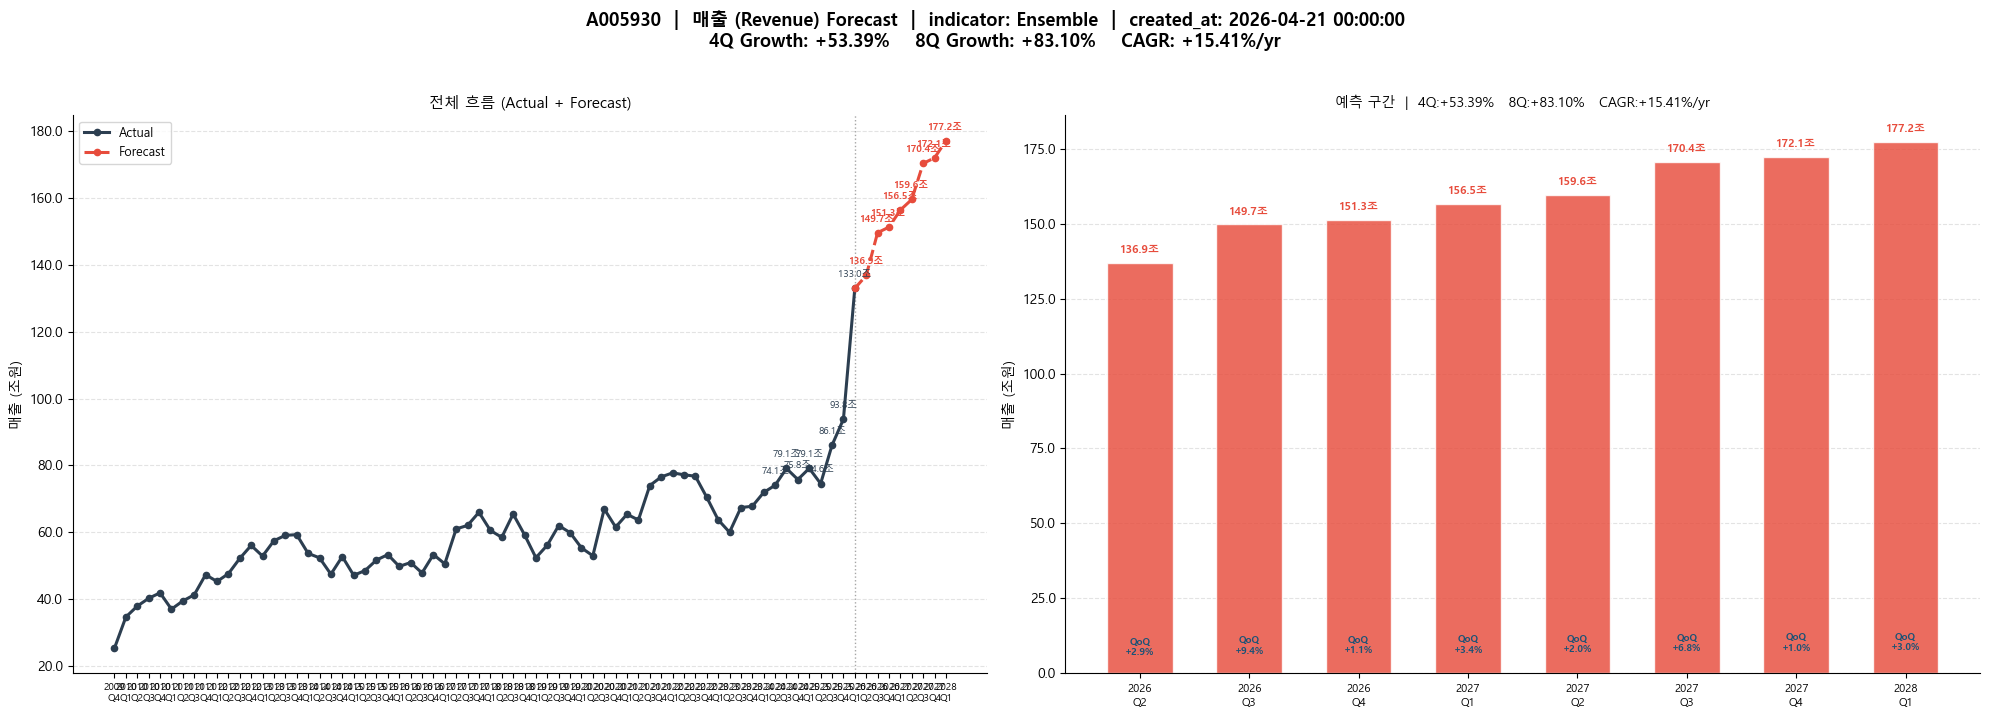

In [11]:
CHART_TICKER = "A005930"     # ← 변경 (예: A000660 SK하이닉스, A035420 NAVER 등)
CHART_MODEL  = "Ensemble"    # ← 변경

plot_ticker_forecast(CHART_TICKER, CHART_MODEL)


## Cell 11 · Best-N 성장률 비교 막대 차트

**위 패널** : 향후 4분기 누적 성장률  
**아래 패널** : 향후 8분기 누적 성장률  
각 막대마다 성장률(%) 값이 표시됩니다.


In [12]:
def plot_best_n_growth(
    best_df: pd.DataFrame,
    model: str,
    forecast_date,
    top_n: int = None,
    w_per_bar: float = 0.72,
):
    '''Best-N 기업의 4Q / 8Q 성장률 상하 2패널 비교 차트'''
    df = best_df.head(top_n).copy() if top_n else best_df.copy()
    tickers = df["ticker"].tolist()
    n       = len(tickers)
    if n == 0:
        print("[WARN] best_df 가 비어있습니다.")
        return
    colors  = (BAR_PALETTE * (n // len(BAR_PALETTE) + 1))[:n]

    has_4q = df["growth_4q_pct"].notna().any()
    has_8q = df["growth_8q_pct"].notna().any()
    n_pnl  = int(has_4q) + int(has_8q)
    if n_pnl == 0:
        print("[WARN] 성장률 데이터가 없습니다.")
        return

    figw  = max(14, n * w_per_bar)
    fig, axes = plt.subplots(n_pnl, 1, figsize=(figw, 5.5 * n_pnl))
    if n_pnl == 1:
        axes = [axes]

    if isinstance(forecast_date, (list, tuple)):
        fd_str = ", ".join(str(d) for d in forecast_date)
    else:
        fd_str = str(forecast_date)

    fig.suptitle(
        f"한국 매출 성장률 Best-{n}  |  indicator: {model}  |  created_at: {fd_str}\n"
        "4Q: 예측4Q합÷실제직전4Q합−1   "
        "8Q: 예측8Q합÷실제최근8Q합−1",
        fontsize=13, fontweight="bold"
    )

    def _draw(ax, raw_vals, title):
        vals = [v if (v is not None and v == v and np.isfinite(v)) else 0
                for v in raw_vals]
        mx   = max(abs(v) for v in vals) if vals else 1

        bars = ax.bar(range(n), vals, color=colors,
                      alpha=0.88, width=0.65, edgecolor="white", zorder=2)

        for bar, v, orig in zip(bars, vals, raw_vals):
            if orig is None or orig != orig or (not np.isfinite(orig)):
                continue
            offset = mx * 0.025
            ypos   = bar.get_height() + (offset if v >= 0 else -offset * 3.8)
            va     = "bottom" if v >= 0 else "top"
            ax.text(
                bar.get_x() + bar.get_width() / 2, ypos,
                f"{v:+.1f}%",
                ha="center", va=va, fontsize=8.5,
                fontweight="bold",
                color="#1A5276" if v >= 0 else "#922B21"
            )

        ax.axhline(0, color="gray", lw=0.9, ls="--", alpha=0.55)
        ax.set_xticks(range(n))
        ax.set_xticklabels(tickers, rotation=40, ha="right", fontsize=9)
        ax.set_ylabel("성장률 (%)", fontsize=10)
        ax.set_title(title, fontsize=12, fontweight="bold", pad=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax.grid(axis="y", ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    pi = 0
    if has_4q:
        _draw(axes[pi], df["growth_4q_pct"].tolist(),
              "향후 4분기 누적 성장률  (예측 4Q합 / 실제 직전 4Q합 − 1)")
        pi += 1
    if has_8q:
        _draw(axes[pi], df["growth_8q_pct"].tolist(),
              "향후 8분기 누적 성장률  (예측 8Q합 / 실제 최근 8Q합 − 1)")

    plt.tight_layout()
    plt.show()


print("[OK] plot_best_n_growth 함수 정의 완료")


[OK] plot_best_n_growth 함수 정의 완료


### Cell 11 실행

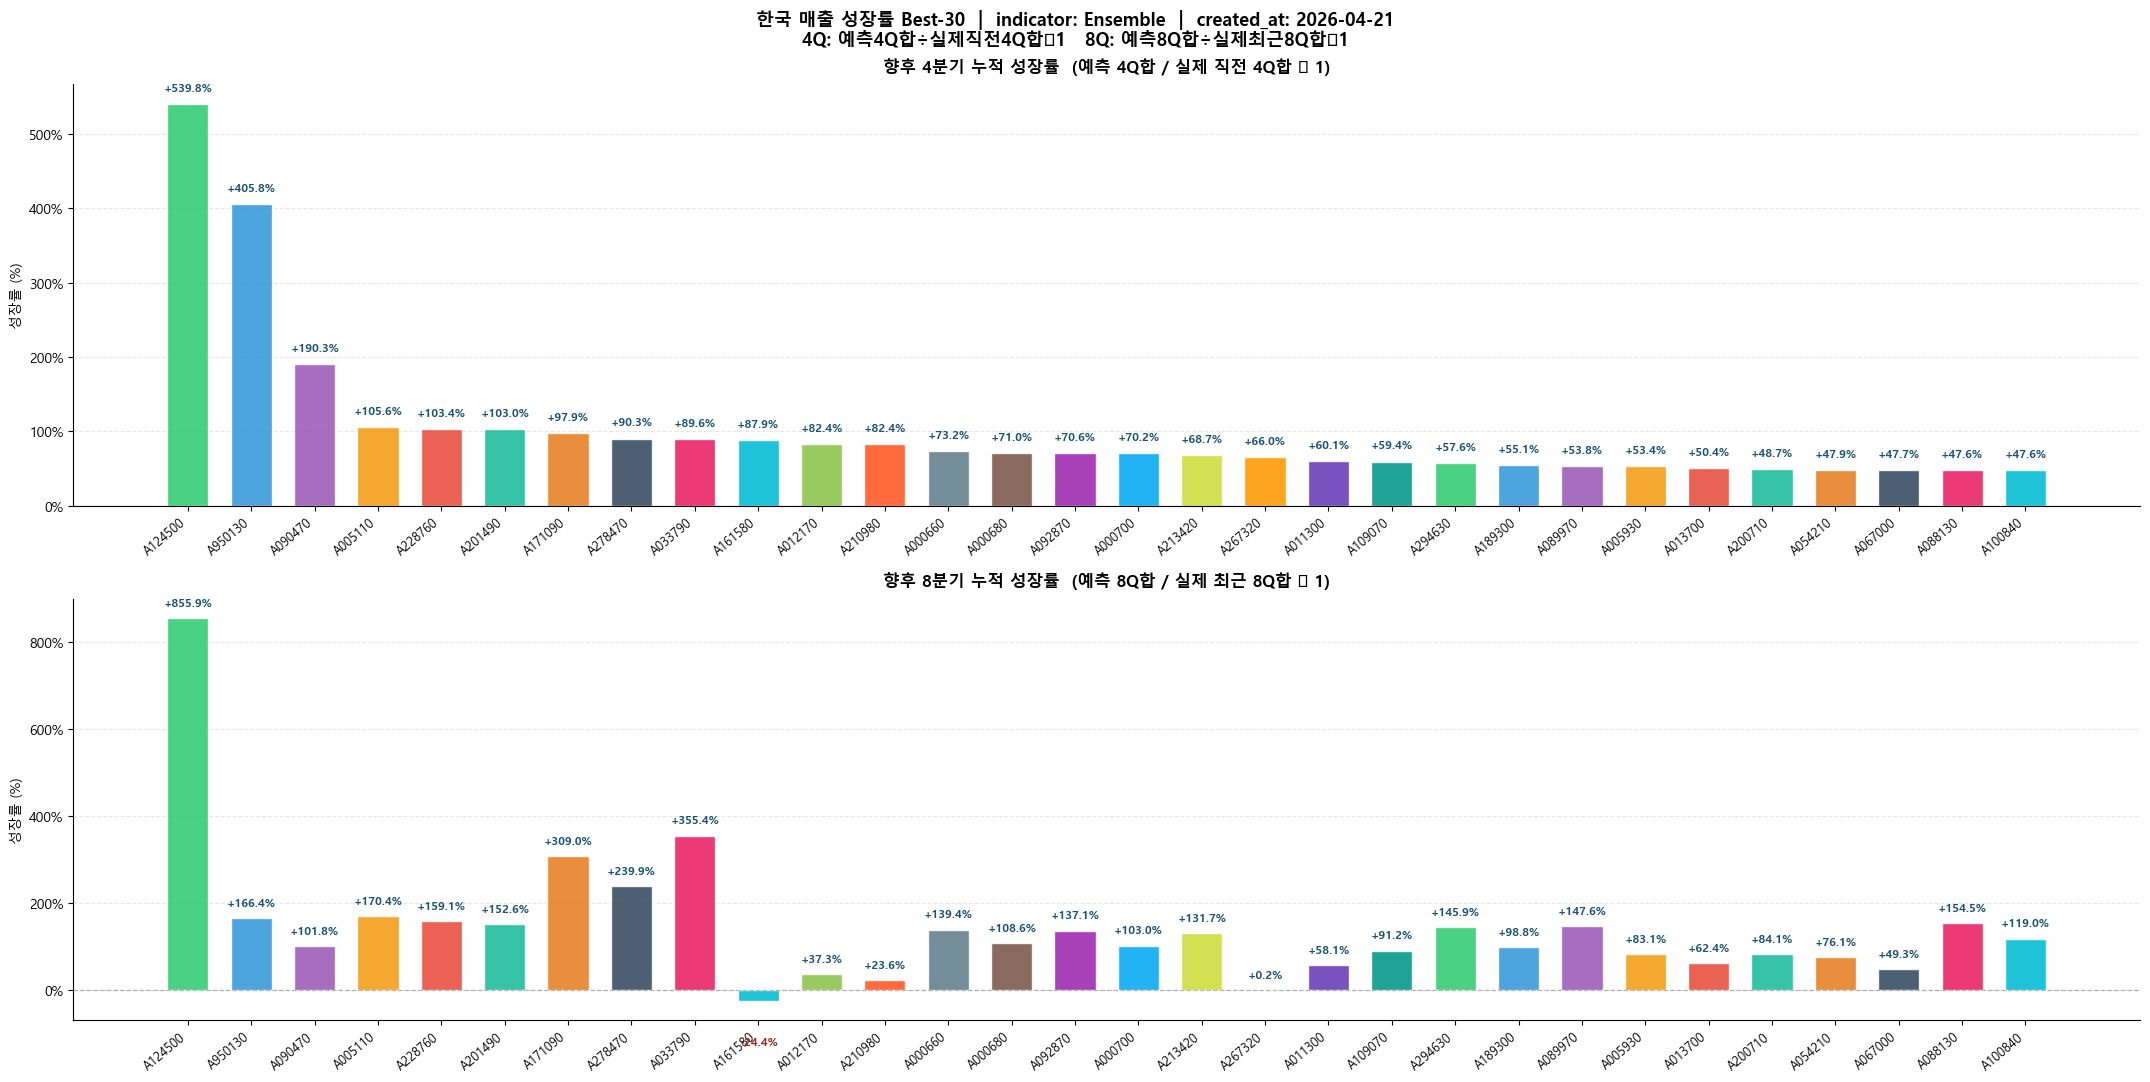

In [13]:
# Cell 8 에서 구한 best_df / used_fd 를 그대로 사용합니다.
# top_n 지정 시 상위 N개만 표시 (None → 전체)
plot_best_n_growth(
    best_df       = best_df,
    model         = BEST_MODEL,
    forecast_date = used_fd,
    top_n         = 30,    # 기본 30개만 표시 (None → 전체 BEST_N)
)
